In [5]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

all_cars = []

url = "https://www.pakwheels.com/used-cars/search/-/ct_karachi/"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")

ads = soup.select("div.well.search-list.ad-container")

for ad in ads:
    try:
        car_name = ad.select_one("a.car-name h3").text.strip()
        city = ad.select_one("ul.search-vehicle-info li").text.strip()
        price = ad.select_one("div.price-details").text.strip()

        detail_items = [li.text.strip() for li in ad.select("ul.search-vehicle-info-2 li")]
        details = " | ".join(detail_items)

        all_cars.append({
            "Car Name": car_name,
            "City": city,
            "Details": details,
            "Price": price,
        })

    except:
        pass

df = pd.DataFrame(all_cars)
df.to_csv("pak_cars.csv", index=False)

print("Scraping Complete → pak_cars.csv generated!")


Scraping Complete → pak_cars.csv generated!


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("pak_cars.csv")

# ----- Clean City -----
df["City"] = df["City"].str.strip()

# ----- Split Details Column -----
df[["Year", "KM", "Fuel", "CC", "Transmission", "Grade"]] = (
    df["Details"]
    .str.split("|", expand=True)
    .apply(lambda col: col.str.strip())
)

# ----- Clean numeric fields -----
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

df["KM"] = (
    df["KM"]
    .str.replace("km", "", regex=False)
    .str.replace(",", "")
    .astype(float)
)

df["CC"] = (
    df["CC"]
    .str.replace("cc", "", regex=False)
    .str.replace(",", "")
    .astype(float)
)

# ----- Clean Price (Working for lacs & crore) -----
def clean_price(price):
    if pd.isna(price):
        return np.nan
    
    p = price.lower().replace("pkr", "").strip()

    if "crore" in p:
        value = p.replace("crore", "").strip()
        return float(value) * 10000000

    if "lacs" in p or "lac" in p:
        value = (
            p.replace("lacs", "")
             .replace("lac", "")
             .replace(",", "")
             .strip()
        )
        return float(value) * 100000

    return float(p.replace(",", "").strip())

df["Price"] = df["Price"].apply(clean_price)

df.to_csv("pak_cars_clean.csv", index=False)
print("Cleaned CSV saved as pak_cars_clean.csv")


Cleaned CSV saved as pak_cars_clean.csv


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("pak_cars_clean.csv")


In [9]:
print(df.head())
print(df.info())
print(df.describe())


                                    Car Name     City  \
0             Daihatsu Mira  2014 L for Sale  Karachi   
1          Suzuki Wagon R  2020 VXL for Sale  Karachi   
2           Toyota Vitz  2009 F 1.0 for Sale  Karachi   
3       Daihatsu Copen  2017 Robe S for Sale  Karachi   
4  Hyundai Santa Fe  2024 Signature for Sale  Karachi   

                                             Details       Price  Year  \
0  2014 | 131,103 km | Petrol | 660 cc | Automati...   2050000.0  2014   
1       2020 | 44,713 km | Petrol | 1000 cc | Manual   3000000.0  2020   
2  2009 | 166,538 km | Petrol | 1000 cc | Automat...   2080000.0  2009   
3     2017 | 54,000 km | Petrol | 660 cc | Automatic   3425000.0  2017   
4     2024 | 1,205 km | Hybrid | 1600 cc | Automatic  15500000.0  2024   

         KM    Fuel      CC Transmission    Grade  
0  131103.0  Petrol   660.0    Automatic  5 Grade  
1   44713.0  Petrol  1000.0       Manual      NaN  
2  166538.0  Petrol  1000.0    Automatic  5 Grade  
3   

In [10]:
df["Brand"] = df["Car Name"].str.split().str[0]

brand_count = df["Brand"].value_counts()
print(brand_count)


Brand
Suzuki      10
Toyota       7
Honda        6
Daihatsu     3
Hyundai      1
Mercedes     1
Proton       1
Name: count, dtype: int64


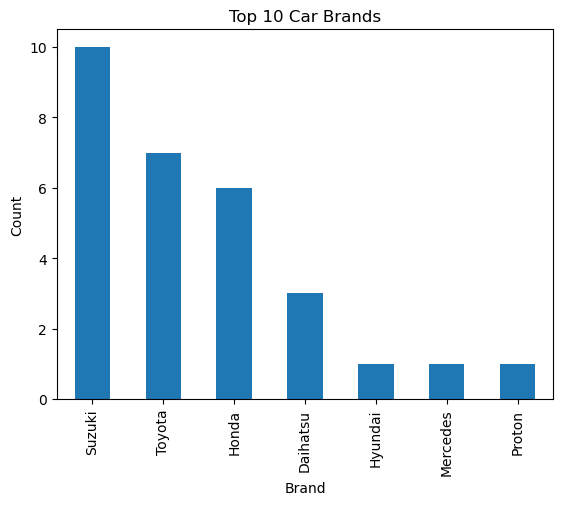

In [11]:
brand_count.head(10).plot(kind="bar")
plt.title("Top 10 Car Brands")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.show()


In [12]:
avg_price = df.groupby("Brand")["Price"].mean().sort_values(ascending=False)
print(avg_price)


Brand
Hyundai     1.550000e+07
Proton      6.800000e+06
Toyota      6.483571e+06
Mercedes    4.800000e+06
Honda       3.083333e+06
Daihatsu    3.041667e+06
Suzuki      1.637000e+06
Name: Price, dtype: float64


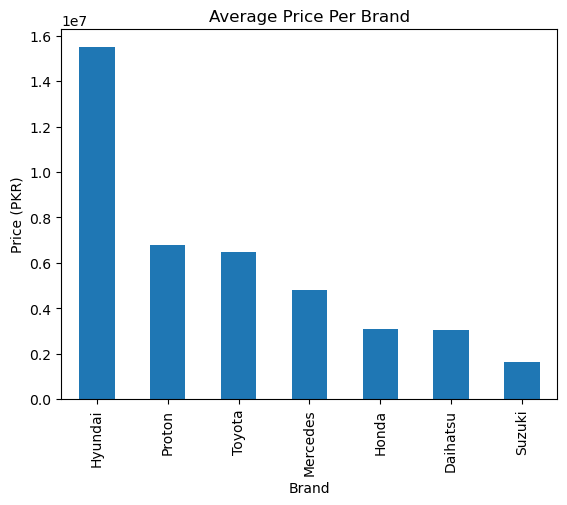

In [13]:
avg_price.head(10).plot(kind="bar")
plt.title("Average Price Per Brand")
plt.ylabel("Price (PKR)")
plt.show()


In [14]:
fuel_count = df["Fuel"].value_counts()
print(fuel_count)


Fuel
Petrol    24
Hybrid     3
Diesel     1
LPG        1
Name: count, dtype: int64


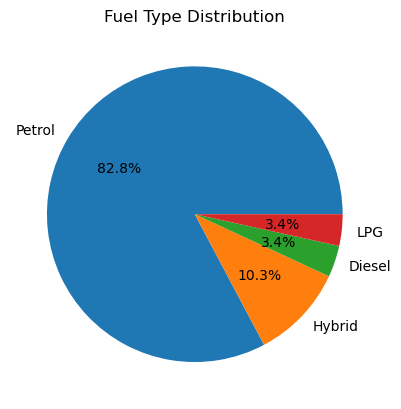

In [15]:
fuel_count.plot(kind="pie", autopct="%1.1f%%")
plt.title("Fuel Type Distribution")
plt.ylabel("")
plt.show()


In [16]:
trans_count = df["Transmission"].value_counts()
print(trans_count)


Transmission
Automatic    18
Manual       11
Name: count, dtype: int64


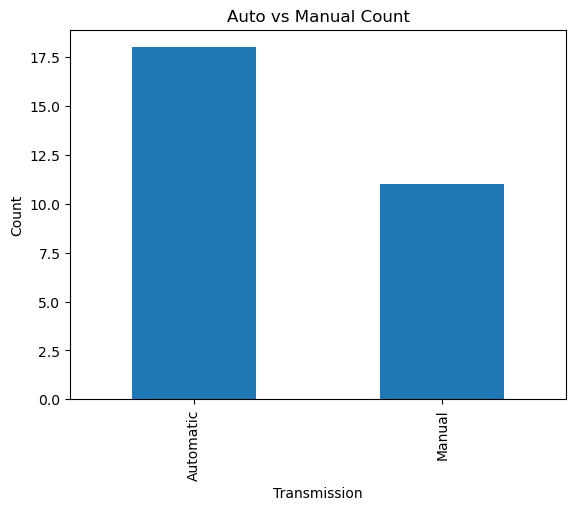

In [17]:
trans_count.plot(kind="bar")
plt.title("Auto vs Manual Count")
plt.ylabel("Count")
plt.show()


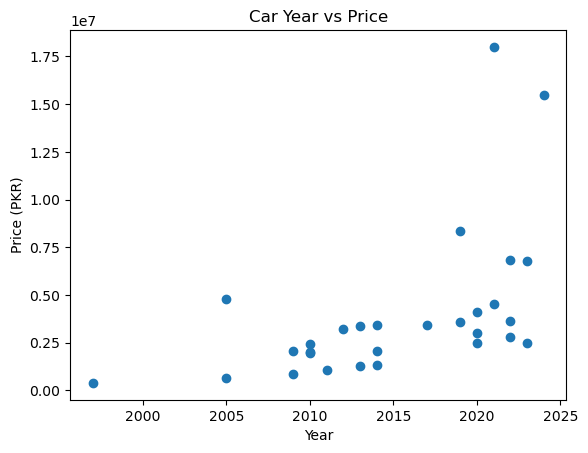

In [18]:
plt.scatter(df["Year"], df["Price"])
plt.title("Car Year vs Price")
plt.xlabel("Year")
plt.ylabel("Price (PKR)")
plt.show()


In [20]:
import pyodbc

# -------------------------------------
# 1. CONNECT TO SQL SERVER (MASTER DB)
# -------------------------------------
conn = pyodbc.connect(
    "DRIVER={SQL Server};"
    "SERVER=DESKTOP-K4EF3Q0;"
    "DATABASE=master;"
    "UID=sa;"          
    "PWD=shah123;",
    autocommit=True      # REQUIRED FOR CREATE DATABASE
)

cursor = conn.cursor()
print("Connected to SQL Server!")


# -------------------------------------
# 2. CHECK IF DATABASE EXISTS
# -------------------------------------
db_name = "PAKWHEEL"

cursor.execute(f"SELECT name FROM sys.databases WHERE name='{db_name}'")
exists = cursor.fetchone()

if exists:
    print(f"Database '{db_name}' already exists.")
else:
    print(f"Database '{db_name}' not found. Creating database...")
    cursor.execute(f"CREATE DATABASE {db_name}")
    print(f"Database '{db_name}' created successfully!")


# -------------------------------------
# 3. CONNECT TO NEW DATABASE
# -------------------------------------
conn_db = pyodbc.connect(
    "DRIVER={SQL Server};"
    "SERVER=DESKTOP-K4EF3Q0;"
    "DATABASE=PAKWHEEL;"
    "UID=sa;"
    "PWD=shah123;"
)

cursor_db = conn_db.cursor()
print("Connected to PAKWHEEL Database!")


# -------------------------------------
# 4. SHOW TABLES IN DATABASE
# -------------------------------------
cursor_db.execute("""
    SELECT TABLE_NAME 
    FROM INFORMATION_SCHEMA.TABLES 
    WHERE TABLE_TYPE='BASE TABLE'
""")

tables = cursor_db.fetchall()

print("\nTables in PAKWHEEL Database:")
if not tables:
    print("No tables found.")
else:
    for t in tables:
        print("-", t[0])


Connected to SQL Server!
Database 'PAKWHEEL' not found. Creating database...
Database 'PAKWHEEL' created successfully!
Connected to PAKWHEEL Database!

Tables in PAKWHEEL Database:
No tables found.


In [ ]:
import pyodbc
import pandas as pd
import numpy as np

# ---------------------------
# 1. Connect to SQL Server
# ---------------------------
conn = pyodbc.connect(
    "DRIVER={SQL Server};"
    "SERVER=DESKTOP-K4EF3Q0;"
    "DATABASE=master;"
    "UID=sa;"
    "PWD=shah123;",
    autocommit=True
)
cursor = conn.cursor()
print("Connected to SQL Server!")

# ---------------------------
# 2. Create Database if not exists
# ---------------------------
db_name = "PAKWHEEL"
cursor.execute(f"SELECT name FROM sys.databases WHERE name='{db_name}'")
exists = cursor.fetchone()

if not exists:
    cursor.execute(f"CREATE DATABASE {db_name}")
    print(f"Database '{db_name}' created successfully!")
else:
    print(f"Database '{db_name}' already exists.")

# ---------------------------
# 3. Connect to PAKWHEEL Database
# ---------------------------
conn_db = pyodbc.connect(
    "DRIVER={SQL Server};"
    "SERVER=DESKTOP-K4EF3Q0;"
    "DATABASE=PAKWHEEL;"
    "UID=sa;"
    "PWD=shah123;",
    autocommit=True
)
cursor_db = conn_db.cursor()
cursor_db.fast_executemany = True
print("Connected to PAKWHEEL database!")

# ---------------------------
# 4. Create Cars Table if not exists
# ---------------------------
create_table_query = """
IF NOT EXISTS (SELECT * FROM sysobjects WHERE name='Cars' AND xtype='U')
CREATE TABLE Cars (
    ID INT IDENTITY(1,1) PRIMARY KEY,
    CarName NVARCHAR(255),
    City NVARCHAR(100),
    Year INT,
    KM FLOAT,
    Fuel NVARCHAR(50),
    CC FLOAT,
    Transmission NVARCHAR(50),
    Grade NVARCHAR(50),
    Price FLOAT
)
"""
cursor_db.execute(create_table_query)
print("Cars table ready!")

# ---------------------------
# 5. Load CSV and Clean Data
# ---------------------------
df = pd.read_csv("pak_cars_clean.csv")

# Strip spaces from column names
df.columns = df.columns.str.strip()

# Clean numeric columns
numeric_cols = ['Year', 'KM', 'CC', 'Price']

for col in numeric_cols:

    df[col] = df[col].astype(str).str.replace(',', '').str.strip()
    # Convert to numeric, invalid parsing -> NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')


df[numeric_cols] = df[numeric_cols].fillna(0)


for index, row in df.iterrows():
    try:
        cursor_db.execute("""
            INSERT INTO Cars (CarName, City, Year, KM, Fuel, CC, Transmission, Grade, Price)
            VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
        """, (
            str(row['Car Name']), str(row['City']), int(row['Year']), float(row['KM']),
            str(row['Fuel']), float(row['CC']), str(row['Transmission']),
            str(row['Grade']), float(row['Price'])
        ))
    except Exception as e:
        print(f"Error inserting row {index}: {e}")
        print("Row data:", row.to_dict())

conn_db.commit()
print("All CSV data inserted into Cars table successfully!")

# ---------------------------
# 7. Show all tables
# ---------------------------
cursor_db.execute("""
    SELECT TABLE_NAME 
    FROM INFORMATION_SCHEMA.TABLES 
    WHERE TABLE_TYPE='BASE TABLE'
""")
tables = cursor_db.fetchall()
print("\nTables in PAKWHEEL Database:")
for t in tables:
    print("-", t[0])


Connected to SQL Server!
Database 'PAKWHEEL' already exists.
Connected to PAKWHEEL database!
Cars table ready!
All CSV data inserted into Cars table successfully!

Tables in PAKWHEEL Database:
- Cars


In [26]:
pip install streamlit pandas matplotlib seaborn plotly


Note: you may need to restart the kernel to use updated packages.


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("pak_cars_clean.csv")

st.title("PakWheels Car Data Analysis")

df["Brand"] = df["Car Name"].str.split().str[0]

st.header("Top 10 Car Brands")
brand_count = df["Brand"].value_counts().head(10)
st.bar_chart(brand_count)

st.header("Average Price by Brand")
avg_price = df.groupby("Brand")["Price"].mean().sort_values(ascending=False).head(10)
st.bar_chart(avg_price)

st.header("Fuel Type Distribution")
st.write(df["Fuel"].value_counts())

st.header("Transmission Count")
st.bar_chart(df["Transmission"].value_counts())

st.header("Year vs Price Scatter Plot")
fig, ax = plt.subplots()
ax.scatter(df["Year"], df["Price"])
st.pyplot(fig)


Writing app.py


: 

In [29]:
import streamlit as st
import pandas as pd
import plotly.express as px

# ---------------------------
# 1. Load Data
# ---------------------------
st.set_page_config(page_title="PakWheels Cars Analysis", layout="wide")
st.title("PakWheels Cars Data Analysis 🚗")

df = pd.read_csv("pak_cars_clean.csv")
df.columns = df.columns.str.strip()

# Add a 'Brand' column from Car Name
df["Brand"] = df["Car Name"].str.split().str[0]

# ---------------------------
# 2. Sidebar Filters
# ---------------------------
st.sidebar.header("Filter Options")

# City filter
cities = df['City'].unique()
selected_city = st.sidebar.multiselect("Select City:", cities, default=cities)

# Fuel filter
fuel_types = df['Fuel'].unique()
selected_fuel = st.sidebar.multiselect("Select Fuel Type:", fuel_types, default=fuel_types)

# Year filter
min_year, max_year = int(df['Year'].min()), int(df['Year'].max())
selected_year = st.sidebar.slider("Select Year Range:", min_year, max_year, (min_year, max_year))

# Apply filters
filtered_df = df[
    (df['City'].isin(selected_city)) &
    (df['Fuel'].isin(selected_fuel)) &
    (df['Year'] >= selected_year[0]) &
    (df['Year'] <= selected_year[1])
]

st.subheader(f"Filtered Data ({filtered_df.shape[0]} cars)")
st.dataframe(filtered_df)

# ---------------------------
# 3. Brand Analysis
# ---------------------------
st.subheader("Top 10 Car Brands by Count")
top_brands = filtered_df["Brand"].value_counts().head(10)
fig = px.bar(x=top_brands.index, y=top_brands.values, labels={'x':'Brand', 'y':'Count'},
             title="Top 10 Car Brands by Count")
st.plotly_chart(fig, use_container_width=True)

st.subheader("Top 10 Brands by Average Price")
avg_price = filtered_df.groupby("Brand")["Price"].mean().sort_values(ascending=False).head(10)
fig = px.bar(x=avg_price.index, y=avg_price.values, labels={'x':'Brand', 'y':'Avg Price'},
             title="Top 10 Brands by Average Price")
st.plotly_chart(fig, use_container_width=True)

# ---------------------------
# 4. Fuel Type Distribution
# ---------------------------
st.subheader("Fuel Type Distribution")
fuel_count = filtered_df["Fuel"].value_counts()
fig = px.pie(values=fuel_count.values, names=fuel_count.index, title="Fuel Type Distribution")
st.plotly_chart(fig, use_container_width=True)

# ---------------------------
# 5. Transmission Count
# ---------------------------
st.subheader("Transmission Count (Auto vs Manual)")
trans_count = filtered_df["Transmission"].value_counts()
fig = px.bar(x=trans_count.index, y=trans_count.values, labels={'x':'Transmission', 'y':'Count'},
             title="Auto vs Manual Count")
st.plotly_chart(fig, use_container_width=True)

# ---------------------------
# 6. Year vs Price Scatter Plot
# ---------------------------
st.subheader("Car Year vs Price")
fig = px.scatter(filtered_df, x="Year", y="Price", color="Fuel", size="CC",
                 hover_data=["Car Name", "City"], title="Year vs Price (by Fuel & CC)")
st.plotly_chart(fig, use_container_width=True)


DeltaGenerator()

SyntaxError: invalid syntax (3737097518.py, line 1)